# Heart Disease Prediction – Full ML Pipeline

**Dataset:** Heart Failure Prediction (`heart.xls`) — 918 samples, 11 features

**Source:** [Kaggle (fedesoriano)](https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction) — CC0 License

**Goal:** Predict the presence of heart disease (binary classification)

In [ ]:
"""
Heart Disease Prediction
=============================================
Dataset: heart.xls (Heart Failure Prediction Dataset)
Source: https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction
"""

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import json
import os

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    f1_score, accuracy_score, roc_curve, precision_recall_curve
)


warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")

SEED = 42
np.random.seed(SEED)

OUT_DIR = "outputs"
os.makedirs(OUT_DIR, exist_ok=True)

## Data Loading & Initial Look

In [32]:
df = pd.read_csv("heart.xls")
print("Shape:", df.shape)
print("Columns:", list(df.columns))
df.head()

Shape: (918, 12)
Columns: ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease']


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


## Quick Overview

In [33]:
print(df.info())
print("\n--- Descriptive Stats ---")#
print(df.describe())

print("\n--- Value counts for target ---")
print(df["HeartDisease"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB
None

--- Descriptive Stats ---
              Age   RestingBP  Cholesterol   FastingBS       MaxHR  \
count  918.000000  918.000000   918.000000  918.000000  918.000000   
mean    53.510893  132.396514 

## Missing Values Check

In [34]:
# Actually just a formality since the value count is already showing there is no missing values in the data
print("Missing values per column:")
print(df.isnull().sum())
# No NaNs, but  checking for suspicious zeros
print(f"\nZero cholesterol entries: {(df['Cholesterol'] == 0).sum()}")
print(f"Zero RestingBP entries: {(df['RestingBP'] == 0).sum()}")

Missing values per column:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

Zero cholesterol entries: 172
Zero RestingBP entries: 1


## EDA – Target Distribution

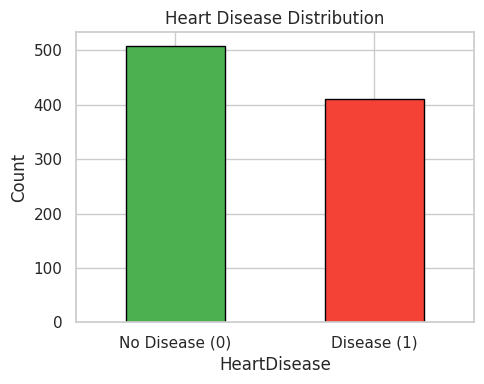

In [35]:
fig, ax = plt.subplots(figsize=(5, 4))
df["HeartDisease"].value_counts().plot.bar(
    color=["#4CAF50", "#F44336"], edgecolor="black", ax=ax
)
ax.set_title("Heart Disease Distribution")
ax.set_xticklabels(["No Disease (0)", "Disease (1)"], rotation=0)
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/target_distribution.png", dpi=150)
plt.show()

## EDA – Numerical Feature Distributions

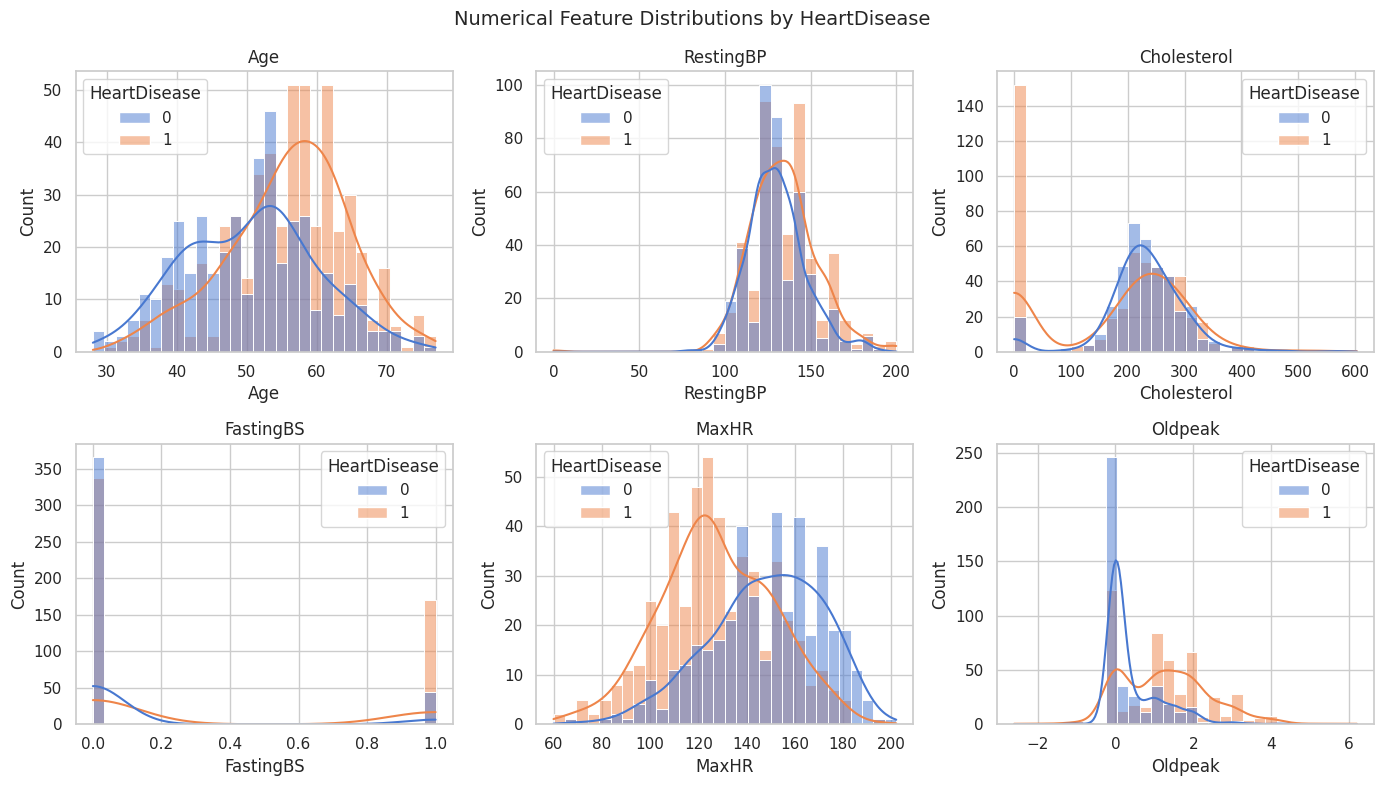

In [36]:
num_cols = df.select_dtypes(include=np.number).columns.drop("HeartDisease")
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for i, col in enumerate(num_cols):
    ax = axes.flat[i]
    sns.histplot(data=df, x=col, hue="HeartDisease", kde=True, ax=ax, bins=30)
    ax.set_title(col)
plt.suptitle("Numerical Feature Distributions by HeartDisease", fontsize=14)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/numerical_distributions.png", dpi=150)
plt.show()

## EDA – Categorical Features vs Target

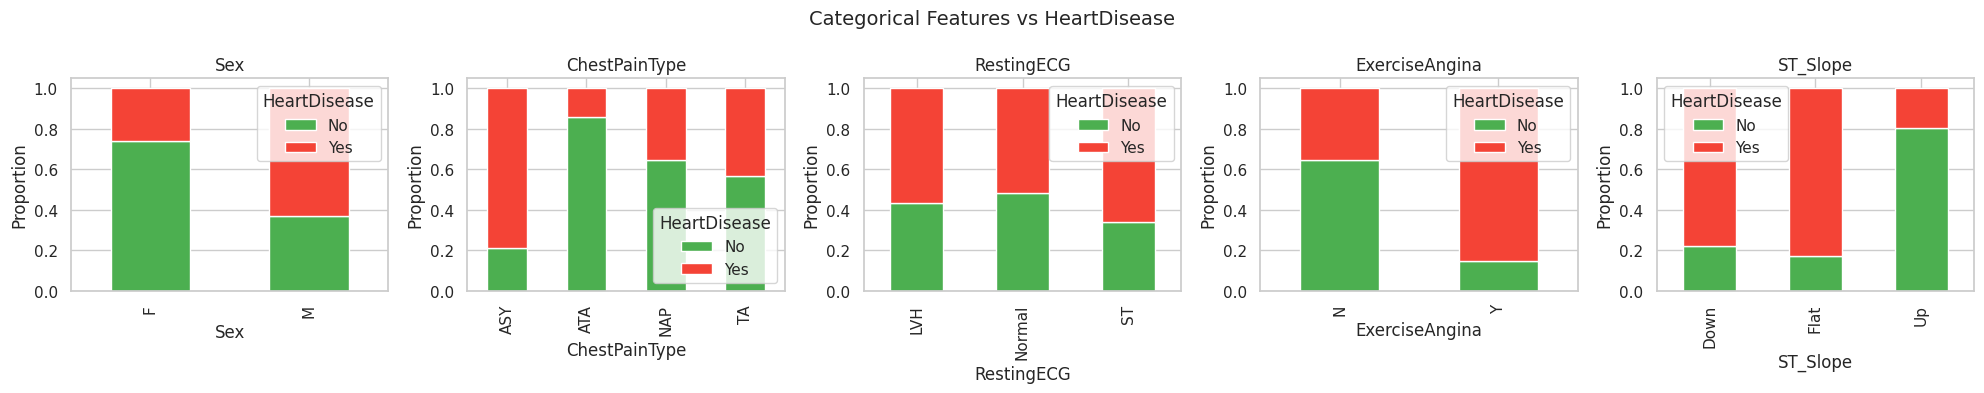

In [37]:
cat_cols = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df["HeartDisease"], normalize="index")
    ct.plot.bar(stacked=True, ax=axes[i], color=["#4CAF50", "#F44336"])
    axes[i].set_title(col)
    axes[i].set_ylabel("Proportion")
    axes[i].legend(["No", "Yes"], title="HeartDisease")
plt.suptitle("Categorical Features vs HeartDisease", fontsize=14)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/categorical_distributions.png", dpi=150)
plt.show()

## Correlation Heatmap

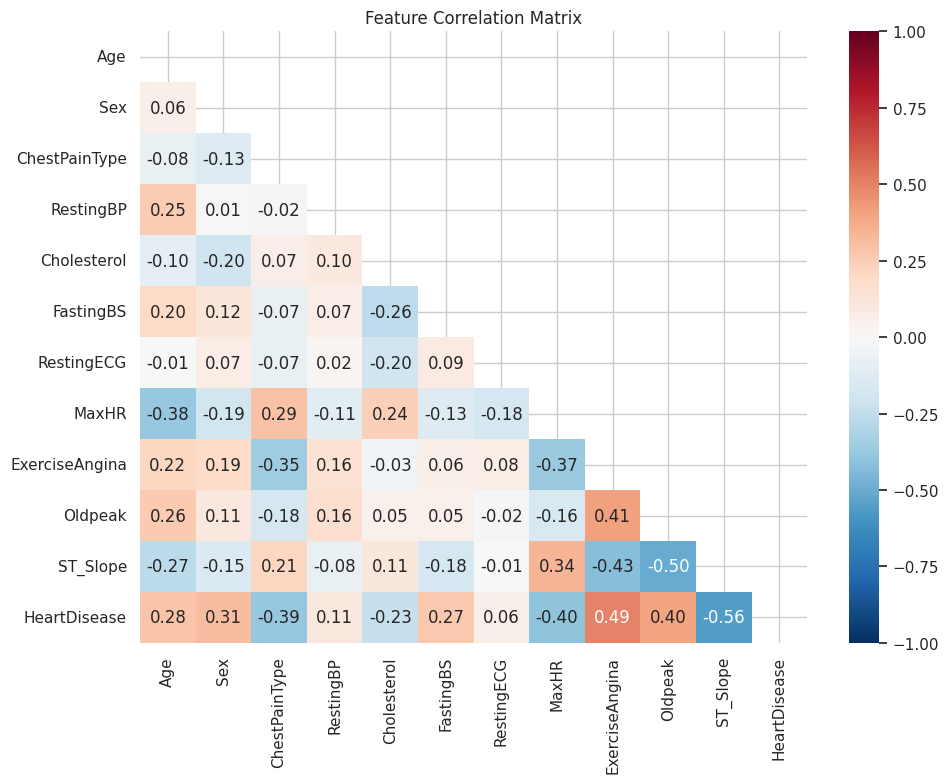

Correlation with HeartDisease:
ExerciseAngina    0.494282
Oldpeak           0.403951
Sex               0.305445
Age               0.282039
FastingBS         0.267291
RestingBP         0.107589
RestingECG        0.057384
Cholesterol      -0.232741
ChestPainType    -0.386828
MaxHR            -0.400421
ST_Slope         -0.558771
Name: HeartDisease, dtype: float64


In [38]:
df_encoded = df.copy()
le_dict = {}
for col in cat_cols:
    le_dict[col] = LabelEncoder()
    df_encoded[col] = le_dict[col].fit_transform(df_encoded[col])

fig, ax = plt.subplots(figsize=(10, 8))
corr = df_encoded.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, ax=ax, vmin=-1, vmax=1)
ax.set_title("Feature Correlation Matrix")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/correlation_matrix.png", dpi=150)
plt.show()

# Strongest correlations with target
print("Correlation with HeartDisease:")
print(corr["HeartDisease"].drop("HeartDisease").sort_values(ascending=False))

## Data Cleaning

172 entries have `Cholesterol = 0`, which is physiologically impossible — these are missing values. We replace them with the median of valid cholesterol readings.

In [39]:
print(f"Cholesterol == 0: {(df_encoded['Cholesterol'] == 0).sum()} / {len(df_encoded)}")
median_chol = df_encoded.loc[df_encoded["Cholesterol"] > 0, "Cholesterol"].median()
print(f"Median of non-zero cholesterol: {median_chol}")
df_encoded.loc[df_encoded["Cholesterol"] == 0, "Cholesterol"] = median_chol

print(f"RestingBP == 0: {(df_encoded['RestingBP'] == 0).sum()}")

if (df_encoded["RestingBP"] == 0).any():
    median_bp = df_encoded.loc[df_encoded["RestingBP"] > 0, "RestingBP"].median()
    df_encoded.loc[df_encoded["RestingBP"] == 0, "RestingBP"] = median_bp

Cholesterol == 0: 172 / 918
Median of non-zero cholesterol: 237.0
RestingBP == 0: 1


## Feature Preparation

In [40]:
X = df_encoded.drop("HeartDisease", axis=1)
y = df_encoded["HeartDisease"]

print("Features:", list(X.columns))
print(f"X shape: {X.shape}, y shape: {y.shape}")
print(f"Class balance: {y.value_counts().to_dict()}")

Features: ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope']
X shape: (918, 11), y shape: (918,)
Class balance: {1: 508, 0: 410}


##Train / Validation / Test Split

Stratified 70/15/15 split to preserve class ratios.

In [41]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=SEED, stratify=y_temp
)

print(f"Train: {X_train.shape[0]}  Val: {X_val.shape[0]}  Test: {X_test.shape[0]}")

Train: 642  Val: 138  Test: 138


## Feature Scaling

In [42]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

## Baseline Models – Comparing 3 Approaches

In [43]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=SEED),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=SEED),
    "GradientBoosting": GradientBoostingClassifier(n_estimators=100, random_state=SEED),
}

results = {}
for name, model in models.items():
    start = time.time()
    model.fit(X_train_s, y_train)
    elapsed = time.time() - start

    val_pred = model.predict(X_val_s)
    val_proba = model.predict_proba(X_val_s)[:, 1]

    acc = accuracy_score(y_val, val_pred)
    f1 = f1_score(y_val, val_pred)
    auroc = roc_auc_score(y_val, val_proba)

    results[name] = {
        "accuracy": round(acc, 4),
        "f1": round(f1, 4),
        "auroc": round(auroc, 4),
        "train_time_s": round(elapsed, 4),
    }
    print(f"{name:25s} | Acc: {acc:.4f} | F1: {f1:.4f} | AUROC: {auroc:.4f} | Time: {elapsed:.3f}s")

LogisticRegression        | Acc: 0.8261 | F1: 0.8421 | AUROC: 0.9094 | Time: 0.049s
RandomForest              | Acc: 0.8188 | F1: 0.8408 | AUROC: 0.9138 | Time: 0.398s
GradientBoosting          | Acc: 0.8333 | F1: 0.8535 | AUROC: 0.9283 | Time: 0.320s


## Model Comparison Chart

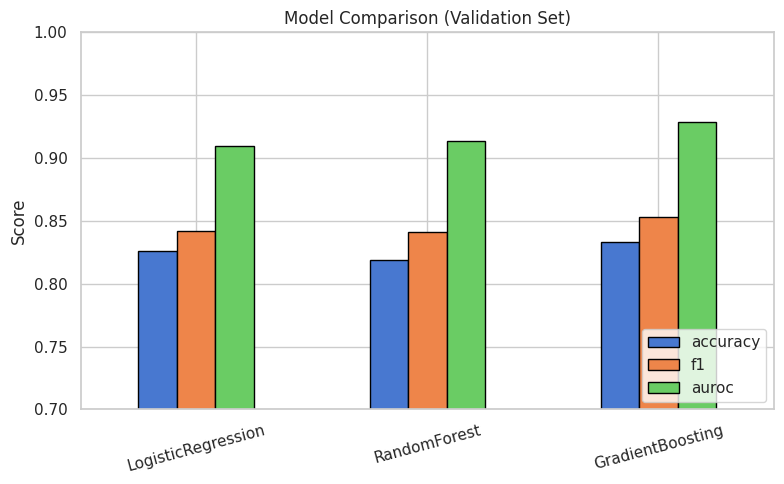

In [44]:
res_df = pd.DataFrame(results).T
fig, ax = plt.subplots(figsize=(8, 5))
res_df[["accuracy", "f1", "auroc"]].plot.bar(ax=ax, edgecolor="black")
ax.set_title("Model Comparison (Validation Set)")
ax.set_ylabel("Score")
ax.set_ylim(0.7, 1.0)
ax.legend(loc="lower right")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/model_comparison.png", dpi=150)
plt.show()

## Hyperparameter Tuning (GridSearchCV)

Tuning both RandomForest and GradientBoosting with 5-fold stratified cross-validation.

In [45]:
# Choosing the model with highest AUROC for tuning
best_baseline = max(results, key=lambda k: results[k]["auroc"])
print(f"Best baseline model: {best_baseline} (AUROC = {results[best_baseline]['auroc']})")

param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, 15, None],
    "min_samples_split": [2, 5],
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=SEED),
    param_grid_rf,
    cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
    scoring="roc_auc",
    n_jobs=-1,
    verbose=0,
)
grid_rf.fit(X_train_s, y_train)
print(f"Best RF params: {grid_rf.best_params_}")
print(f"Best CV AUROC:  {grid_rf.best_score_:.4f}")

# Also tuning GradientBoosting
param_grid_gb = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.05, 0.1, 0.2],
}

grid_gb = GridSearchCV(
    GradientBoostingClassifier(random_state=SEED),
    param_grid_gb,
    cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
    scoring="roc_auc",
    n_jobs=-1,
    verbose=0,
)
grid_gb.fit(X_train_s, y_train)
print(f"Best GB params: {grid_gb.best_params_}")
print(f"Best CV AUROC:  {grid_gb.best_score_:.4f}")

# final best
if grid_gb.best_score_ > grid_rf.best_score_:
    best_model = grid_gb.best_estimator_
    best_name = "GradientBoosting (tuned)"
    best_cv_auroc = grid_gb.best_score_
    best_params = grid_gb.best_params_
else:
    best_model = grid_rf.best_estimator_
    best_name = "RandomForest (tuned)"
    best_cv_auroc = grid_rf.best_score_
    best_params = grid_rf.best_params_

print(f"\n>>> Final model: {best_name}")
print(f">>> Best params: {best_params}")
print(f">>> CV AUROC:    {best_cv_auroc:.4f}")

Best baseline model: GradientBoosting (AUROC = 0.9283)
Best RF params: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}
Best CV AUROC:  0.9255
Best GB params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Best CV AUROC:  0.9178

>>> Final model: RandomForest (tuned)
>>> Best params: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}
>>> CV AUROC:    0.9255


## Final Model – Validation Results

In [46]:
val_pred = best_model.predict(X_val_s)
val_proba = best_model.predict_proba(X_val_s)[:, 1]

val_acc = accuracy_score(y_val, val_pred)
val_f1 = f1_score(y_val, val_pred)
val_auroc = roc_auc_score(y_val, val_proba)

print(f"\n=== Final Model Validation Results ({best_name})")
print(f"Accuracy : {val_acc:.4f}")
print(f"F1 Score : {val_f1:.4f}")
print(f"AUROC    : {val_auroc:.4f}")
print("\nClassification Report:")
print(classification_report(y_val, val_pred))


=== Final Model Validation Results (RandomForest (tuned))
Accuracy : 0.8261
F1 Score : 0.8462
AUROC    : 0.9204

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.77      0.80        62
           1       0.82      0.87      0.85        76

    accuracy                           0.83       138
   macro avg       0.83      0.82      0.82       138
weighted avg       0.83      0.83      0.83       138



## Confusion Matrix

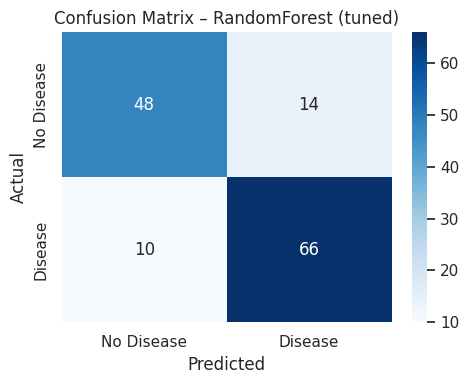

True Negatives: 48, False Positives: 14
False Negatives: 10, True Positives: 66


In [47]:
cm = confusion_matrix(y_val, val_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["No Disease", "Disease"],
            yticklabels=["No Disease", "Disease"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"Confusion Matrix – {best_name}")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/confusion_matrix.png", dpi=150)
plt.show()

print(f"True Negatives: {cm[0,0]}, False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]}, True Positives: {cm[1,1]}")

## ROC Curve

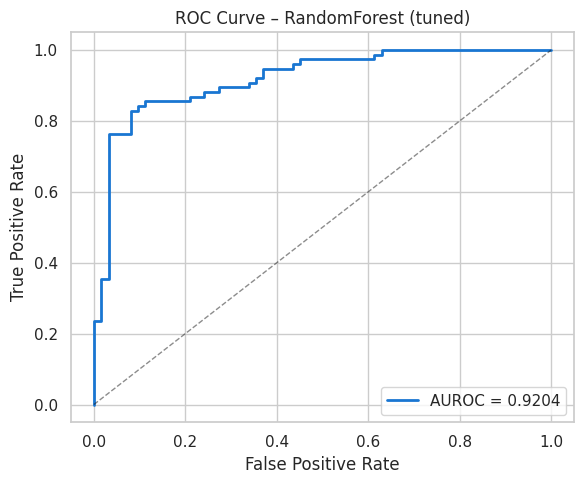

In [48]:
fpr, tpr, thresholds = roc_curve(y_val, val_proba)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color="#1976D2", lw=2, label=f"AUROC = {val_auroc:.4f}")
ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(f"ROC Curve – {best_name}")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/roc_curve.png", dpi=150)
plt.show()

##  Precision-Recall Curve

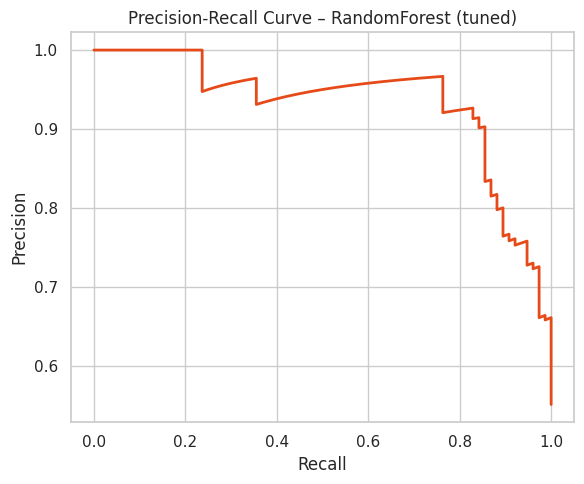

In [49]:
prec, rec, _ = precision_recall_curve(y_val, val_proba)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(rec, prec, color="#E64A19", lw=2)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title(f"Precision-Recall Curve – {best_name}")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/precision_recall_curve.png", dpi=150)
plt.show()

## Feature Importance

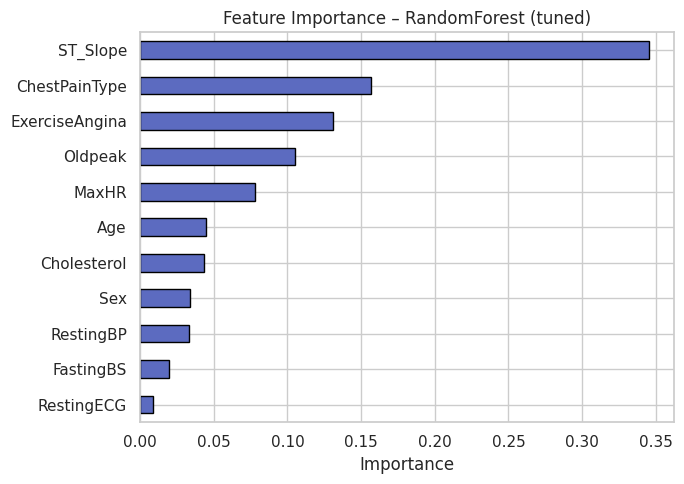

Feature importances (sorted):
  ST_Slope: 0.3451
  ChestPainType: 0.1565
  ExerciseAngina: 0.1309
  Oldpeak: 0.1055
  MaxHR: 0.0780
  Age: 0.0449
  Cholesterol: 0.0432
  Sex: 0.0341
  RestingBP: 0.0330
  FastingBS: 0.0199
  RestingECG: 0.0089


In [50]:
if hasattr(best_model, "feature_importances_"):
    importances = best_model.feature_importances_
else:
    importances = np.abs(best_model.coef_[0])

feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(7, 5))
feat_imp.plot.barh(ax=ax, color="#5C6BC0", edgecolor="black")
ax.set_title(f"Feature Importance – {best_name}")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/feature_importance.png", dpi=150)
plt.show()

print("Feature importances (sorted):")
for feat, imp in feat_imp[::-1].items():
    print(f"  {feat}: {imp:.4f}")

## Error Analysis – Misclassifications

In [51]:
val_df = pd.DataFrame(X_val_s, columns=X.columns)
val_df["y_true"] = y_val.values
val_df["y_pred"] = val_pred
val_df["y_proba"] = val_proba

false_positives = val_df[(val_df["y_true"] == 0) & (val_df["y_pred"] == 1)]
false_negatives = val_df[(val_df["y_true"] == 1) & (val_df["y_pred"] == 0)]

print(f"False Positives: {len(false_positives)}")
print(f"False Negatives: {len(false_negatives)}")

print("\n--- False Positive stats (scaled features) ---")
print(false_positives[X.columns].describe().loc[["mean"]])
print("\n--- False Negative stats (scaled features) ---")
print(false_negatives[X.columns].describe().loc[["mean"]])

False Positives: 14
False Negatives: 10

--- False Positive stats (scaled features) ---
           Age       Sex  ChestPainType  RestingBP  Cholesterol  FastingBS  \
mean  0.423712 -0.180799       0.070931   -0.09462    -0.228028  -0.352256   

      RestingECG     MaxHR  ExerciseAngina   Oldpeak  ST_Slope  
mean   -0.429605  0.168907        0.622986  0.172312 -0.093833  

--- False Negative stats (scaled features) ---
           Age       Sex  ChestPainType  RestingBP  Cholesterol  FastingBS  \
mean -0.168322  0.273703      -0.296307  -0.662186     0.049718  -0.282885   

      RestingECG     MaxHR  ExerciseAngina   Oldpeak  ST_Slope  
mean   -0.611356  0.817858       -0.830346 -0.778071  0.918028  


## Bias Analysis – Gender Fairness

In [52]:
print("\n=== Gender Bias Analysis ===")
# Reconstructing original Sex values for the val set
val_sex = X_val["Sex"].values  # Already encoded: 0=F, 1=M

for sex_val, sex_name in [(0, "Female"), (1, "Male")]:
    mask = val_sex == sex_val
    if mask.sum() == 0:
        print(f"{sex_name}: no samples in val set")
        continue
    sub_proba = val_proba[mask]
    sub_true = y_val.values[mask]
    sub_pred = val_pred[mask]
    sub_auroc = roc_auc_score(sub_true, sub_proba) if len(np.unique(sub_true)) > 1 else float("nan")
    sub_acc = accuracy_score(sub_true, sub_pred)
    print(f"{sex_name}: n={mask.sum()}, Acc={sub_acc:.4f}, AUROC={sub_auroc:.4f}")

# overall gender distribution
print(f"\nGender distribution in full dataset:")
print(df["Sex"].value_counts())


=== Gender Bias Analysis ===
Female: n=27, Acc=0.8148, AUROC=0.9365
Male: n=111, Acc=0.8288, AUROC=0.9118

Gender distribution in full dataset:
Sex
M    725
F    193
Name: count, dtype: int64


## 5-Fold Cross-Validation (Full Data)

In [53]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_auroc = cross_val_score(best_model, scaler.transform(X), y, cv=cv, scoring="roc_auc")
cv_f1 = cross_val_score(best_model, scaler.transform(X), y, cv=cv, scoring="f1")

print(f"\n=== 5-Fold CV Results ({best_name}) ==")
print(f"AUROC: {cv_auroc.mean():.4f} ± {cv_auroc.std():.4f}  | per fold: {np.round(cv_auroc, 4)}")
print(f"F1:    {cv_f1.mean():.4f} ± {cv_f1.std():.4f}  | per fold: {np.round(cv_f1, 4)}")


=== 5-Fold CV Results (RandomForest (tuned)) ==
AUROC: 0.9248 ± 0.0241  | per fold: [0.9451 0.9351 0.8895 0.9507 0.9034]
F1:    0.8698 ± 0.0267  | per fold: [0.9064 0.8529 0.8585 0.8952 0.8357]


## Final Test Set Evaluation


=== Final Test Set Results (RandomForest (tuned))
Accuracy : 0.8841
F1 Score : 0.8961
AUROC    : 0.9249

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.88      0.85      0.87        62
           1       0.88      0.91      0.90        76

    accuracy                           0.88       138
   macro avg       0.88      0.88      0.88       138
weighted avg       0.88      0.88      0.88       138



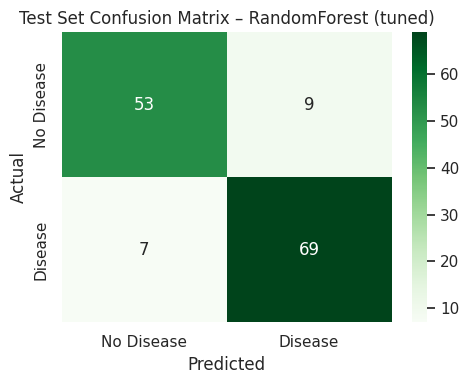

In [54]:
test_pred = best_model.predict(X_test_s)
test_proba = best_model.predict_proba(X_test_s)[:, 1]

test_acc = accuracy_score(y_test, test_pred)
test_f1 = f1_score(y_test, test_pred)
test_auroc = roc_auc_score(y_test, test_proba)

print(f"\n=== Final Test Set Results ({best_name})")
print(f"Accuracy : {test_acc:.4f}")
print(f"F1 Score : {test_f1:.4f}")
print(f"AUROC    : {test_auroc:.4f}")
print("\nClassification Report (Test):")
print(classification_report(y_test, test_pred))

cm_test = confusion_matrix(y_test, test_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_test, annot=True, fmt="d", cmap="Greens", ax=ax,
            xticklabels=["No Disease", "Disease"],
            yticklabels=["No Disease", "Disease"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"Test Set Confusion Matrix – {best_name}")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/test_confusion_matrix.png", dpi=150)
plt.show()

## Save Results

In [55]:
log = {
    "model": best_name,
    "best_params": {k: (int(v) if isinstance(v, (np.integer,)) else v) for k, v in best_params.items()},
    "validation": {"accuracy": val_acc, "f1": val_f1, "auroc": val_auroc},
    "test": {"accuracy": test_acc, "f1": test_f1, "auroc": test_auroc},
    "cv_auroc_mean": float(cv_auroc.mean()),
    "cv_auroc_std": float(cv_auroc.std()),
    "cv_f1_mean": float(cv_f1.mean()),
    "seed": SEED,
    "train_size": len(X_train),
    "val_size": len(X_val),
    "test_size": len(X_test),
}

with open(f"{OUT_DIR}/training_log.json", "w") as f:
    json.dump(log, f, indent=2, default=str)

print(f"\nAll outputs saved to {OUT_DIR}/")
print("Done.")


All outputs saved to outputs/
Done.


To reproduce my  notebook:
```bash
pip install -r requirements.txt
Download or import the data from Kaggle and add to root. Make sure you are using the .xls file. After run all the codes chronologically
OR
jupyter nbconvert --to notebook --execute heart_disease_analysis.ipynb
```

All random seeds are fixed at `42` (NumPy, scikit-learn `random_state`). Results should be identical on the same scikit-learn version.

In [2]:
!pip show scikit-learn

Name: scikit-learn
Version: 1.6.1
Summary: A set of python modules for machine learning and data mining
Home-page: https://scikit-learn.org
Author: 
Author-email: 
License: BSD 3-Clause License

 Copyright (c) 2007-2024 The scikit-learn developers.
 All rights reserved.

 Redistribution and use in source and binary forms, with or without
 modification, are permitted provided that the following conditions are met:

 * Redistributions of source code must retain the above copyright notice, this
   list of conditions and the following disclaimer.

 * Redistributions in binary form must reproduce the above copyright notice,
   this list of conditions and the following disclaimer in the documentation
   and/or other materials provided with the distribution.

 * Neither the name of the copyright holder nor the names of its
   contributors may be used to endorse or promote products derived from
   this software without specific prior written permission.

 THIS SOFTWARE IS PROVIDED BY THE COPYR